In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
#from ydata_profiling import ProfileReport
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder
import warnings
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
import pickle
from sklearn.pipeline import Pipeline
%matplotlib inline

In [3]:
df = pd.read_csv(r"C:\Users\de\Downloads\ipl_data.csv")

In [4]:
df

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76009,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,121,7,19.2,40,0,40,12,129
76010,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,127,7,19.3,46,0,46,12,129
76011,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,128,7,19.4,47,0,47,12,129
76012,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,MG Johnson,DT Christian,129,7,19.5,48,0,47,13,129


In [6]:
df.head()

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


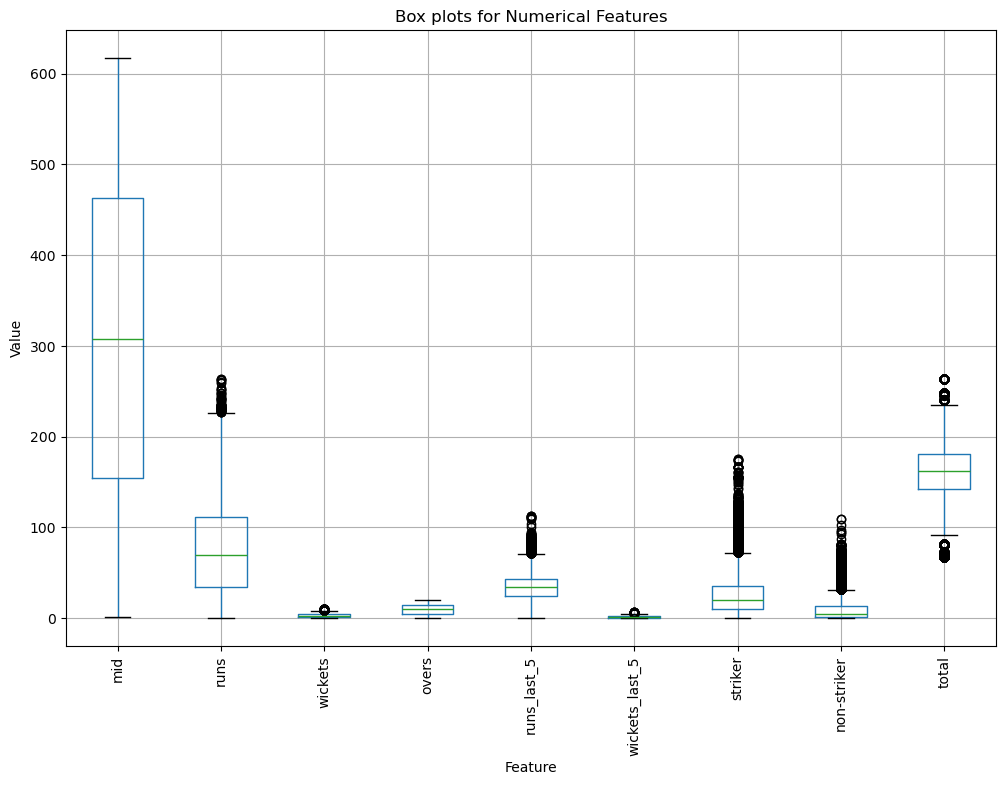

In [7]:
# Select numerical columns
numerical_cols = df.select_dtypes(include=['int', 'float']).columns

# Create box plots for all numerical features
plt.figure(figsize=(12, 8))
df[numerical_cols].boxplot()
plt.xticks(rotation=90)
plt.title('Box plots for Numerical Features')
plt.ylabel('Value')
plt.xlabel('Feature')
plt.show()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76014 entries, 0 to 76013
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mid             76014 non-null  int64  
 1   date            76014 non-null  object 
 2   venue           76014 non-null  object 
 3   bat_team        76014 non-null  object 
 4   bowl_team       76014 non-null  object 
 5   batsman         76014 non-null  object 
 6   bowler          76014 non-null  object 
 7   runs            76014 non-null  int64  
 8   wickets         76014 non-null  int64  
 9   overs           76014 non-null  float64
 10  runs_last_5     76014 non-null  int64  
 11  wickets_last_5  76014 non-null  int64  
 12  striker         76014 non-null  int64  
 13  non-striker     76014 non-null  int64  
 14  total           76014 non-null  int64  
dtypes: float64(1), int64(8), object(6)
memory usage: 8.7+ MB


In [9]:
df.describe()

,mid,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
count,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000
mean,308.627740,74.889349,2.415844,9.783068,33.216434,1.120307,24.962283,8.869287,160.901452
std,178.156878,48.823327,2.015207,5.772587,14.914174,1.053343,20.079752,10.795742,29.246231
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.000000
25%,154.000000,34.000000,1.000000,4.600000,24.000000,0.000000,10.000000,1.000000,142.000000
50%,308.000000,70.000000,2.000000,9.600000,34.000000,1.000000,20.000000,5.000000,162.000000
75%,463.000000,111.000000,4.000000,14.600000,43.000000,2.000000,35.000000,13.000000,181.000000
max,617.000000,263.000000,10.000000,19.600000,113.000000,7.000000,175.000000,109.000000,263.000000


In [10]:
df.describe(include = "O")

,date,venue,bat_team,bowl_team,batsman,bowler
count,76014,76014,76014,76014,76014,76014
unique,442,35,14,14,411,329
top,2010-03-25,M Chinnaswamy Stadium,Mumbai Indians,Delhi Daredevils,SK Raina,Harbhajan Singh
freq,257,7443,10213,10245,1921,1404


<Axes: >

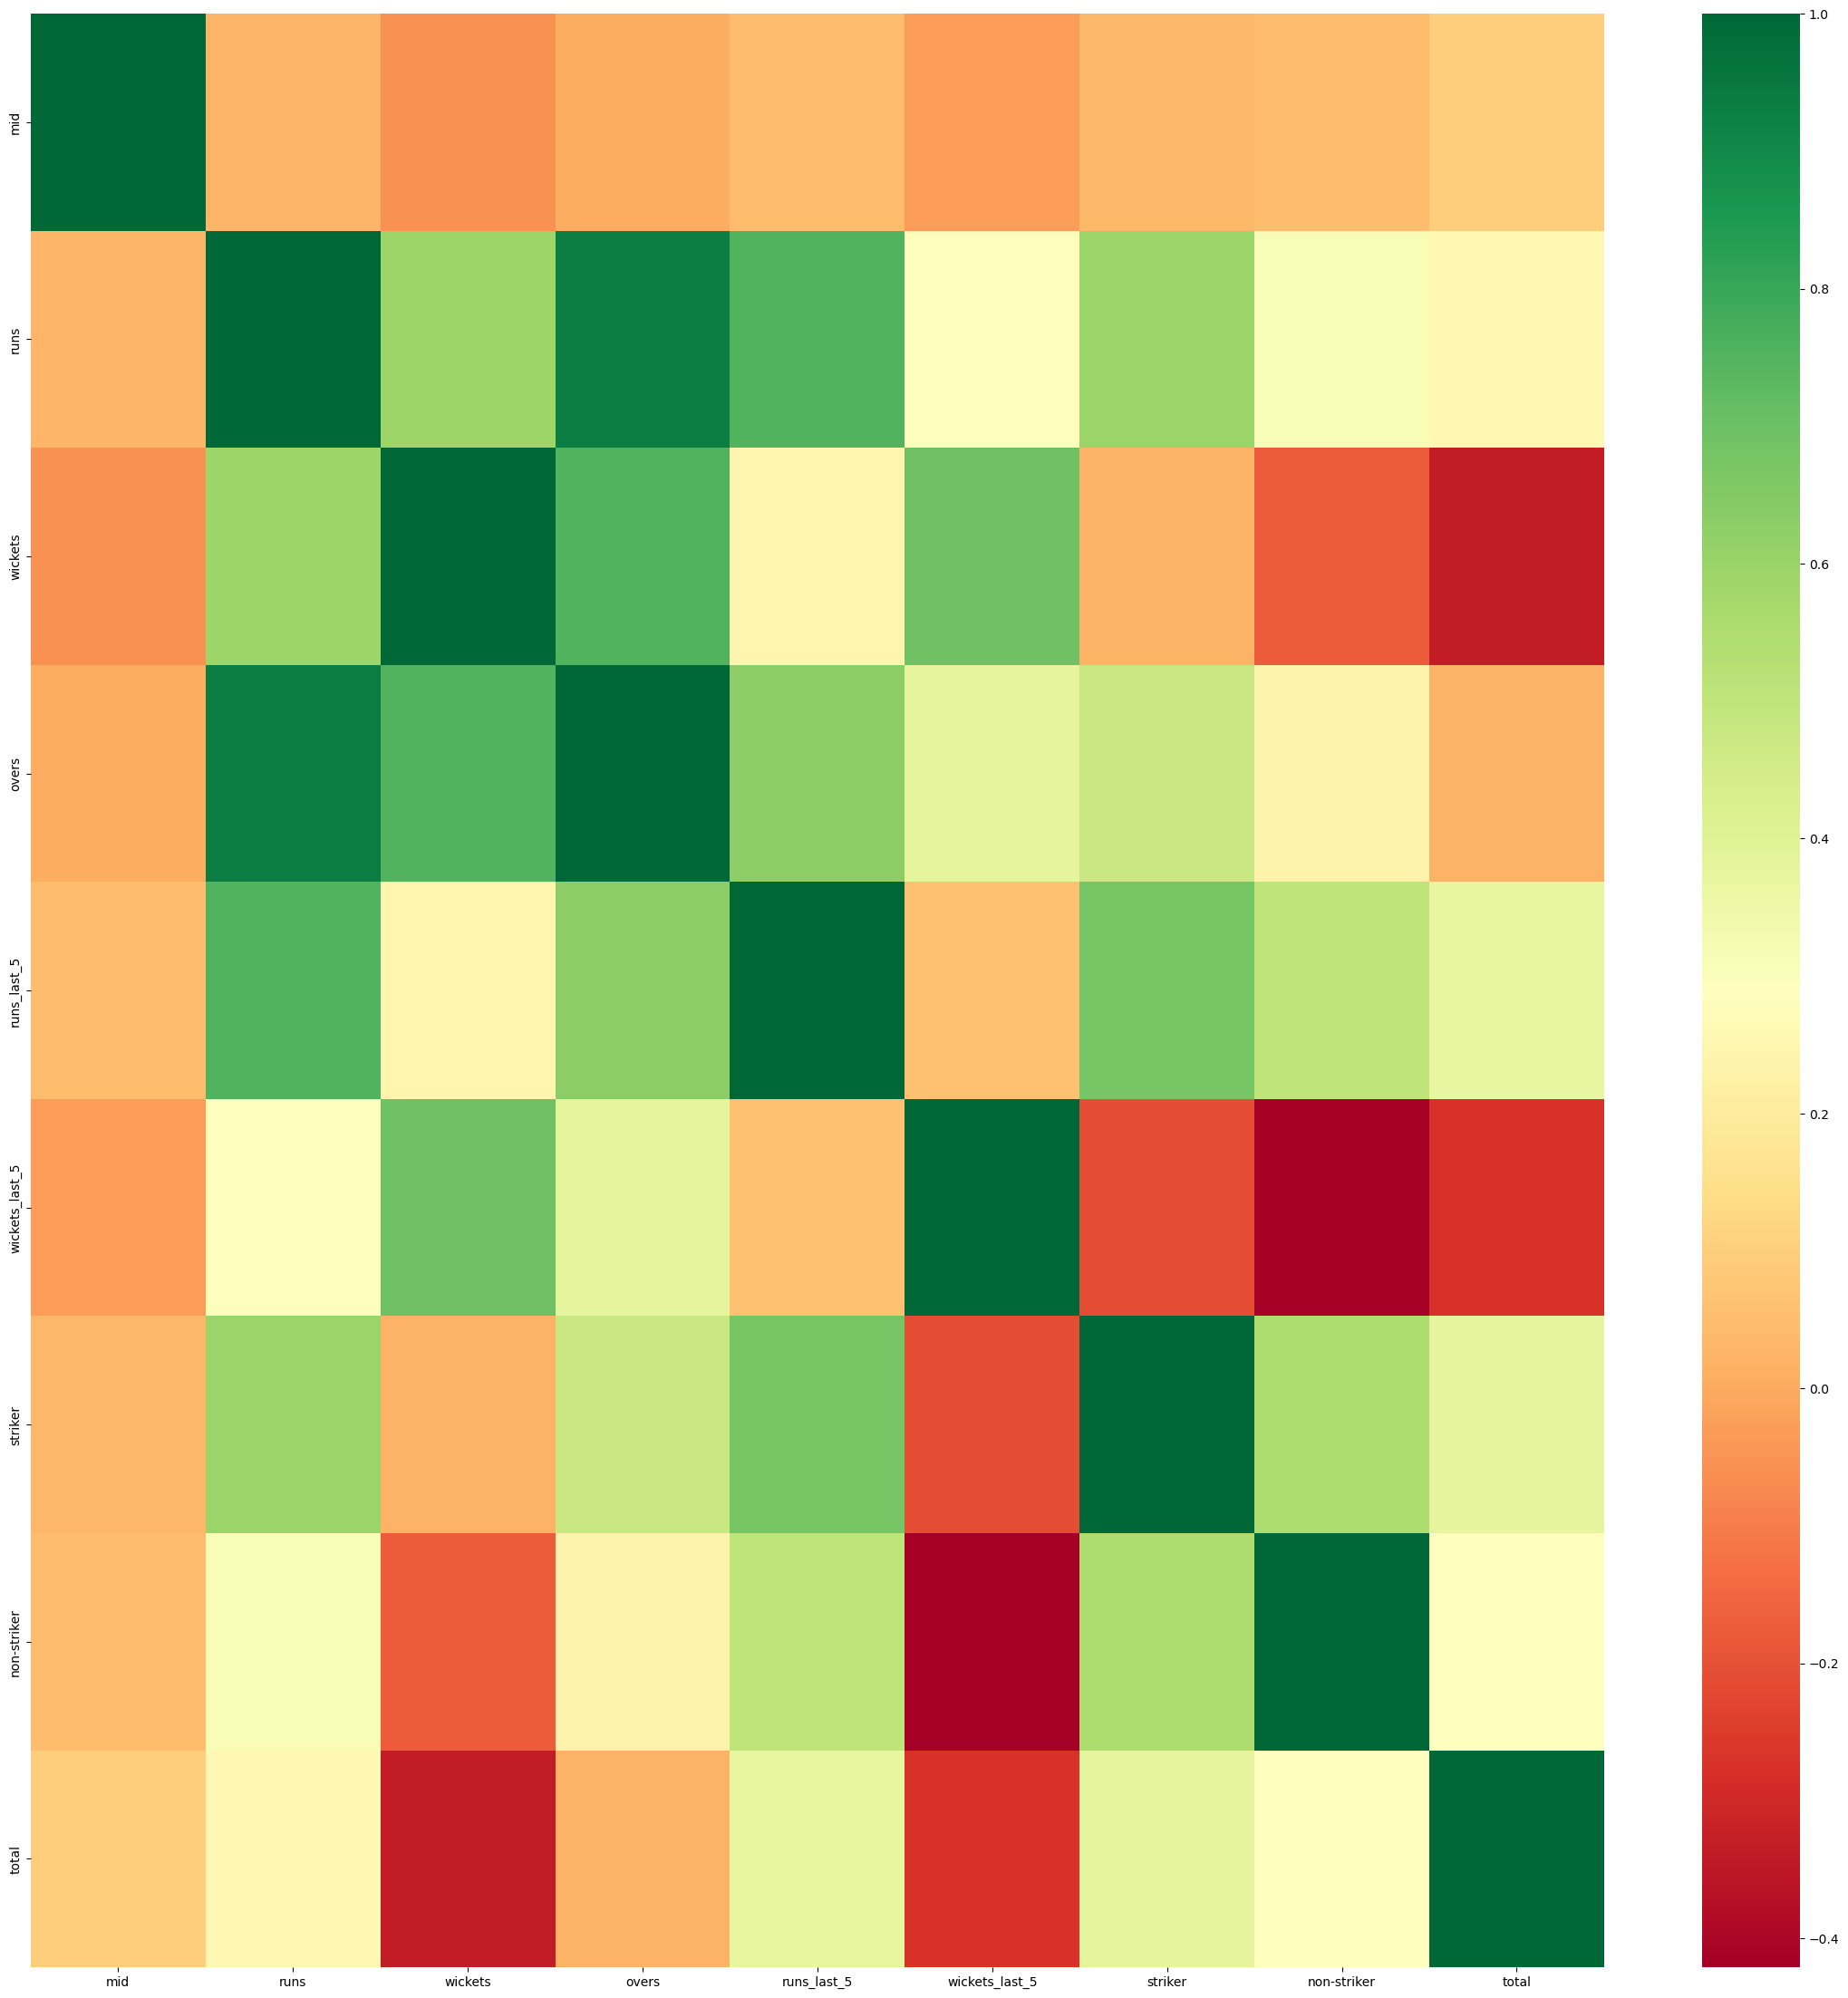

In [11]:
plt.figure(figsize=(28,28))#increase plot size
sns.heatmap(df.select_dtypes(include=['int', 'float']).corr(),cmap="RdYlGn")

In [12]:
np.where(df.select_dtypes(include=['int', 'float']).corr()>0.9)

(array([0, 1, 1, 2, 3, 3, 4, 5, 6, 7, 8]),
 array([0, 1, 3, 2, 1, 3, 4, 5, 6, 7, 8]))

In [13]:
df.columns

Index(['mid', 'date', 'venue', 'bat_team', 'bowl_team', 'batsman', 'bowler',
       'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5', 'striker',
       'non-striker', 'total'],
      dtype='object')

In [14]:
df[['mid', 'date', 'venue', 'bat_team', 'bowl_team', 'batsman', 'bowler',
       'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5', 'striker',
       'non-striker', 'total']]

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76009,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,121,7,19.2,40,0,40,12,129
76010,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,127,7,19.3,46,0,46,12,129
76011,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian,128,7,19.4,47,0,47,12,129
76012,617,2017-05-21,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,MG Johnson,DT Christian,129,7,19.5,48,0,47,13,129


In [15]:
df['venue'].value_counts()

venue
M Chinnaswamy Stadium                                   7443
Feroz Shah Kotla                                        7068
Eden Gardens                                            7049
Wankhede Stadium                                        7048
MA Chidambaram Stadium, Chepauk                         5972
Rajiv Gandhi International Stadium, Uppal               5827
Punjab Cricket Association Stadium, Mohali              4247
Sawai Mansingh Stadium                                  4110
Dr DY Patil Sports Academy                              2088
Subrata Roy Sahara Stadium                              2086
Maharashtra Cricket Association Stadium                 1843
Kingsmead                                               1731
Sardar Patel Stadium, Motera                            1484
Brabourne Stadium                                       1380
SuperSport Park                                         1377
Punjab Cricket Association IS Bindra Stadium, Mohali    1342
Saurashtra Cricket

In [16]:
df['bat_team'].value_counts()

bat_team
Mumbai Indians                 10213
Kings XI Punjab                 9219
Chennai Super Kings             9142
Royal Challengers Bangalore     8331
Kolkata Knight Riders           8033
Delhi Daredevils                7152
Rajasthan Royals                6643
Deccan Chargers                 5280
Sunrisers Hyderabad             5216
Pune Warriors                   2448
Gujarat Lions                   1726
Rising Pune Supergiant           994
Kochi Tuskers Kerala             876
Rising Pune Supergiants          741
Name: count, dtype: int64

In [17]:
df['bowl_team'].value_counts()

bowl_team
Delhi Daredevils               10245
Royal Challengers Bangalore     9661
Mumbai Indians                  9271
Kolkata Knight Riders           9211
Kings XI Punjab                 8405
Rajasthan Royals                7773
Chennai Super Kings             6497
Deccan Chargers                 3984
Sunrisers Hyderabad             3589
Pune Warriors                   3083
Gujarat Lions                   1970
Rising Pune Supergiant           962
Kochi Tuskers Kerala             736
Rising Pune Supergiants          627
Name: count, dtype: int64

In [18]:
df['batsman'].value_counts()

batsman
SK Raina          1921
V Kohli           1825
S Dhawan          1730
RG Sharma         1726
MS Dhoni          1584
                  ... 
T Henderson          1
NJ Rimmington        1
LH Ferguson          1
P Parameswaran       1
V Pratap Singh       1
Name: count, Length: 411, dtype: int64

In [19]:
df['bowler'].value_counts()

bowler
Harbhajan Singh    1404
PP Chawla          1399
P Kumar            1386
SL Malinga         1333
UT Yadav           1304
                   ... 
DB Ravi Teja          6
KS Williamson         6
CK Kapugedera         6
P Prasanth            6
SA Yadav              6
Name: count, Length: 329, dtype: int64

In [20]:
df['runs'].value_counts()

runs
1      895
0      808
5      697
2      649
4      643
      ... 
259      1
253      1
245      1
239      1
240      1
Name: count, Length: 252, dtype: int64

In [21]:
df['wickets'].value_counts()

wickets
1     14900
0     14840
2     13927
3     11568
4      9124
5      5208
6      3334
7      1784
8       856
9       426
10       47
Name: count, dtype: int64

In [22]:
df['overs'].value_counts()

overs
0.1     655
0.4     652
1.1     650
3.5     649
2.3     649
       ... 
8.0      17
13.0     15
12.0     14
11.0     14
10.0     11
Name: count, Length: 140, dtype: int64

In [23]:
df['runs_last_5'].value_counts()

runs_last_5
34     2408
33     2328
35     2317
36     2289
32     2281
       ... 
95        1
100       1
104       1
109       1
113       1
Name: count, Length: 102, dtype: int64

In [24]:
df['wickets_last_5'].value_counts()

wickets_last_5
1    27238
0    24918
2    16102
3     5802
4     1534
5      350
6       65
7        5
Name: count, dtype: int64

In [25]:
df['striker'].value_counts()

striker
4      2266
1      2188
5      2087
6      1993
10     1981
       ... 
173       1
148       1
132       1
152       1
158       1
Name: count, Length: 155, dtype: int64

In [26]:
df['non-striker'].value_counts()

non-striker
0      12246
1       9642
2       6210
3       4174
4       3994
       ...  
78         1
87         1
93         1
97         1
103        1
Name: count, Length: 88, dtype: int64

In [27]:
df['total'].value_counts()

total
165    1746
178    1505
183    1495
163    1485
168    1485
       ... 
98      110
103     103
73       98
81       96
70       91
Name: count, Length: 138, dtype: int64

In [28]:
df['mid'].value_counts()

mid
309    132
32     131
115    131
106    131
299    131
      ... 
403     91
241     74
479     65
495     63
384     50
Name: count, Length: 617, dtype: int64

In [29]:
df['date'].value_counts()

date
2010-03-25    257
2011-04-22    257
2012-05-20    256
2015-04-25    255
2014-05-14    254
             ... 
2014-05-02    103
2008-05-07    103
2008-05-16     98
2012-04-05     74
2015-05-13     63
Name: count, Length: 442, dtype: int64

In [30]:
len(df.columns)

15

In [31]:
OHE_columns=['venue']
standard_scaler=['runs','overs']
label_encoder=['venue']
pass_through=['non-striker']

In [32]:
class ModifiedLabelEncoder(LabelEncoder):
    def fit_transform(self, y, *args, **kwargs):
        return super().fit_transform(y).reshape(-1, 1)

    def transform(self, y, *args, **kwargs):
        return super().transform(y).reshape(-1, 1)

In [33]:
def same(x):
    return x

In [34]:
no_trans=FunctionTransformer(same)

In [35]:
preprocessor = ColumnTransformer([
    ("OHE_columns", OneHotEncoder(), OHE_columns),
    ("Label_encoder", ModifiedLabelEncoder(), label_encoder),
    ("Standard_scaler", StandardScaler(), standard_scaler),
    ('Pass_through',no_trans,pass_through)])

In [36]:
preprocessor

,transformers,"[('OHE_columns', ...), ('Label_encoder', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


In [37]:
import pickle

with open("dtrfpreprocesspickle.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

In [38]:
df.isnull().sum() 

mid               0
date              0
venue             0
bat_team          0
bowl_team         0
batsman           0
bowler            0
runs              0
wickets           0
overs             0
runs_last_5       0
wickets_last_5    0
striker           0
non-striker       0
total             0
dtype: int64

In [39]:
X = df.drop("total",axis=1) 
y = df["total"]

In [40]:
import pickle   # importing pickle for saving and loading machine learning models
import pandas as pd  # importing pandas for analyzing, cleaning, exploring, and manipulating data
from sklearn.model_selection import train_test_split  # importing train_test_split for spliting the data into training and testing
#from preprocessor import *  # importing * for import all functions at once
from imblearn.over_sampling import SMOTE  # importing SMOTE for Balancing the Data

In [41]:
# Spliting the data into train and test
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=33)

In [42]:
from sklearn.preprocessing import LabelEncoder

class ModifiedLabelEncoder(LabelEncoder):
    def fit_transform(self, y, *args, **kwargs):
        return super().fit_transform(y).reshape(-1, 1)

    def transform(self, y, *args, **kwargs):
        return super().transform(y).reshape(-1, 1)


In [43]:
def same(x):
    return x

In [45]:
# Load a preprocessor object from a pickled file
with open(r"C:\Users\de\dtrfpreprocesspickle.pkl","rb")as f:
    preprocessor=pickle.load(f)

In [46]:
preprocessor

,transformers,"[('OHE_columns', ...), ('Label_encoder', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


In [49]:
# Transform the training data using the preprocessor object or PipeLine
processed_x_train = preprocessor.fit_transform(x_train)
processed_x_test = preprocessor.transform(x_test)

C:\Users\de\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\de\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [48]:
processed_x_train[0]  # Checking first rows of processed_x_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5 stored elements and shape (1, 39)>

In [50]:
from sklearn.ensemble import RandomForestRegressor


In [51]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)


In [52]:
rf.fit(processed_x_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [53]:
y_pred = rf.predict(processed_x_test)


In [54]:
y_pred

array([139.52      , 150.19216667, 165.45      , ..., 158.78      ,
       155.70833333, 150.03      ], shape=(19004,))

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)


MAE: 10.617311155522849
MSE: 267.06174807581436
RMSE: 16.34202398957407
R² Score: 0.6888936224744617


In [56]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, 40, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(processed_x_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Best Score: 0.6461019542727493


In [58]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)

rf.fit(processed_x_train, y_train)

y_pred = rf.predict(processed_x_test)


In [59]:
best_rf = random_search.best_estimator_

y_pred = best_rf.predict(processed_x_test)


In [60]:
y_pred

array([144.66073317, 148.83004766, 163.20359954, ..., 161.84060253,
       159.29476523, 152.24637031], shape=(19004,))

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 11.512795381067074
MSE: 281.5086281423455
RMSE: 16.778218860842934
R² Score: 0.6720641193485835


In [62]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(processed_x_train, y_train)

y_pred = gb.predict(processed_x_test)


In [63]:
y_pred

array([157.15606219, 157.67903935, 174.35545416, ..., 158.99938455,
       155.47742432, 147.56454603], shape=(19004,))

In [64]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


R2: 0.4803460804100763
MAE: 15.376854282490124
RMSE: 21.12070887648724


In [65]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor

param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 1.0]
}

gb = GradientBoostingRegressor(random_state=42)

random_search = RandomizedSearchCV(
    gb,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(processed_x_train, y_train)

print(random_search.best_params_)


{'subsample': 1.0, 'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 5, 'learning_rate': 0.2}


In [66]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)

gb.fit(processed_x_train, y_train)

y_pred_gb = gb.predict(processed_x_test)


In [67]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R2:", r2_score(y_test, y_pred_gb))
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))


R2: 0.4803460804100763
MAE: 15.376854282490124
RMSE: 21.12070887648724


In [69]:
# Opening a file named "model.pkl" in write-binary mode
# The 'wb' mode is used for writing binary data to the file
with open("model.pkl","wb") as f:
    pickle.dump(best_rf,f)      # Using pickle to serialize and save the grid search object to the file

In [70]:
!pip install xgboost


In [71]:
from xgboost import XGBRegressor


In [72]:
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(processed_x_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [73]:
y_pred = xgb.predict(processed_x_test)


In [74]:
y_pred

array([156.35178, 157.09488, 172.9791 , ..., 157.82271, 158.98357,
       149.56442], shape=(19004,), dtype=float32)

In [75]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


R² Score: 0.5479230880737305
MAE: 14.207282066345215
RMSE: 19.699606427748833


In [76]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'min_child_weight': [1, 3, 5]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring='r2',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(processed_x_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 1.0}
Best CV Score: 0.623376190662384


In [77]:
best_xgb = random_search.best_estimator_

y_pred = best_xgb.predict(processed_x_test)

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


R²: 0.6496051549911499
MAE: 11.99303913116455
RMSE: 17.343239716592386


In [78]:
import pickle

with open("xgboost_model.pkl", "wb") as f:
    pickle.dump(best_xgb, f)
